# 08 · Residual connections + LayerNorm — keeping deep stacks trainable

Two small pieces let us stack dozens of blocks without training collapsing:

- **Residual (skip) connection:** `x + sublayer(x)`. Add the input back to the output so
  information and gradients flow **straight through** many layers. Fights vanishing gradients
  and "forgetting".
- **LayerNorm:** rescale each token's vector to mean 0, variance 1, so numbers stay in a sane
  range and training doesn't blow up.

Modern models use **pre-norm** (normalize *before* the sublayer): `x + sublayer(norm(x))` —
it trains more stably than the original post-norm.

In [1]:
import numpy as np
np.random.seed(0)

def layer_norm(x, eps=1e-5):
    mu  = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return (x - mu) / np.sqrt(var + eps)          # per-token: center, then scale to unit variance

X = np.random.randn(4, 8) * 5 + 10                # deliberately off-center, large spread
Xn = layer_norm(X)
print("before: mean", X.mean(-1).round(2),  "std", X.std(-1).round(2))
print("after : mean", Xn.mean(-1).round(2), "std", Xn.std(-1).round(2), " <- ~0 mean, ~1 std")
assert np.allclose(Xn.mean(-1), 0, atol=1e-6)

before: mean [14.42 12.23  9.36 12.63] std [5.11 2.26 5.92 5.52]
after : mean [ 0. -0. -0.  0.] std [1. 1. 1. 1.]  <- ~0 mean, ~1 std


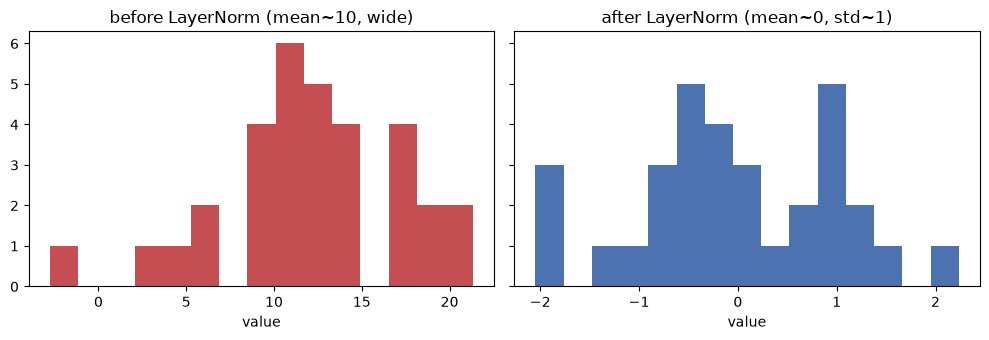

In [2]:
# Visual: LayerNorm pulls each token's values to mean 0 / std 1.
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
a1.hist(X.ravel(),  bins=15, color="#C44E52"); a1.set_title("before LayerNorm (mean~10, wide)")
a2.hist(Xn.ravel(), bins=15, color="#4C72B0"); a2.set_title("after LayerNorm (mean~0, std~1)")
for a in (a1, a2): a.set_xlabel("value")
plt.tight_layout(); plt.show()

### Where they sit in a block (pre-norm)
```
x ──┬──────────────► norm ─► sublayer ─►(+)──► ...
    └───────────────────────────────────┘   the '+' is the residual: original x added back
```
**Takeaway.** Residual = a highway that skips each sublayer; LayerNorm = keep the numbers
tame. Together they make 96-layer stacks trainable. Next: **09 · the full block**.